In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import math
import os
import warnings
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
dataset_path = r"C:\Users\user\Datasets\hv_double_line_90kv"

data_path = os.path.join(dataset_path, "all")
labels_path = os.path.join(dataset_path, "labels.csv")

# Check if dataset paths exist
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data path does not exist: {data_path}")
if not os.path.exists(labels_path):
    raise FileNotFoundError(f"Labels path does not exist: {labels_path}")

# Print number of files in data path
num_files = len(os.listdir(data_path))
print(f"Number of files in data path: {num_files}")

# Print number of lines in labels file
with open(labels_path, "r") as f:
    num_lines = sum(1 for line in f)

print(f"Number of lines in labels file: {num_lines}")

Number of files in data path: 9857
Number of lines in labels file: 9151


In [4]:
# Task: Read in the "rep_id" column, check for duplicates, and print the number of unique "rep_id"s
labels_df = pd.read_csv(labels_path, sep=";")
rep_ids = labels_df["rep_id"]
num_duplicates = rep_ids.duplicated().sum()
num_unique_rep_ids = rep_ids.nunique()

print(f"Number of duplicate rep_id entries: {num_duplicates}")
print(f"Number of unique rep_id entries: {num_unique_rep_ids}")

Number of duplicate rep_id entries: 0
Number of unique rep_id entries: 9150


In [5]:
# example data file: "C:\Users\user\Datasets\hv_double_line_90kv\all\replica_0.txt"

# Task: Iterate trough the rep_id column and check if the corresponding data file exists in the data path
missing_files = []

for rep_id in rep_ids:
    data_file = os.path.join(data_path, f"replica_{rep_id}.txt")
    if not os.path.exists(data_file):
        missing_files.append(rep_id)

if missing_files:
    print(f"Missing data files for rep_id entries: {missing_files}")
    print(f"Total missing files: {len(missing_files)}")
else:
    print("All data files exist for the given rep_id entries.")

# Task: Create labels_filtered.csv with only the entries that have corresponding data files
filtered_labels_df = labels_df[~labels_df["rep_id"].isin(missing_files)]

filtered_labels_path = os.path.join(dataset_path, "labels_filtered.csv")
filtered_labels_df.to_csv(filtered_labels_path, sep=";", index=False)
print(f"Filtered labels saved to: {filtered_labels_path}")
print(f"Number of entries in filtered labels: {len(filtered_labels_df)}")

Missing data files for rep_id entries: [23, 45, 63, 75, 76, 146, 176, 212, 267, 355, 423, 581, 668, 688, 741, 882, 897, 952, 1018, 1095, 1151, 1159, 1192, 1259, 1342, 1426, 1449, 1497, 1609, 1753, 1846, 1858, 2032, 2467, 2489, 2554, 2736, 2995, 3287, 3456, 3597, 3658, 3743, 3787, 4024, 4181, 4200, 4271, 4295, 4348, 4351, 4361, 4455, 4562, 4779, 4827, 4840, 5009, 5019, 5067, 5144, 5332, 5381, 5438, 5443, 5526, 5568, 5578, 5734, 5750, 5812, 5853, 5879, 5894, 5912, 6144, 6192, 6199, 6265, 6307, 6332, 6407, 6412, 6417, 6470, 6545, 6604, 6628, 6659, 6731, 6761, 6854, 6883, 6944, 6989, 7002, 7016, 7069, 7111, 7251, 7272, 7298, 7330, 7336, 7400, 7490, 7592, 7687, 7757, 7774, 7811, 7895, 8109, 8147, 8198, 8337, 8352, 8359, 8570, 8574, 8625, 8652, 8675, 8701, 8815, 8944, 8989, 9057]
Total missing files: 128
Filtered labels saved to: C:\Users\user\Datasets\hv_double_line_90kv\labels_filtered.csv
Number of entries in filtered labels: 9022


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(filtered_labels_path, sep=";")
N = len(df)

# Mapping from your code (hv_double_line_90kv / test_hv_double_line_90kv)
SC_TYPE_TO_EVENT = {0: "3ph_shc", 1: "2ph_shc", 2: "1phg_shc", 3: "2phg_shc"}
PHASE_SELECT_TO_TAG_2PH = {0: "AB", 1: "BC", 2: "CA"}
PHASE_SELECT_TO_TAG_1PH = {0: "A", 1: "B", 2: "C"}


def fault_label_from_row(row: pd.Series) -> str:
    sc = int(row["sc_type"])
    ps = int(row["phase_select"])

    if sc == 0:
        return "ABC"  # 3ph
    if sc == 1:
        return PHASE_SELECT_TO_TAG_2PH[ps]  # AB/BC/CA
    if sc == 2:
        return PHASE_SELECT_TO_TAG_1PH[ps] + "G"  # AG/BG/CG
    if sc == 3:
        return PHASE_SELECT_TO_TAG_2PH[ps] + "G"  # ABG/BCG/CAG
    return f"sc{sc}"


df["event_type"] = df["sc_type"].map(SC_TYPE_TO_EVENT)
df["fault_class"] = df.apply(fault_label_from_row, axis=1)


def dist_to_latex(
    dist_df: pd.DataFrame, first_col: str, caption: str, label: str
) -> str:
    d = dist_df.copy()
    d["share_pct"] = (d["count"] / N * 100).map(lambda x: f"{x:.2f}")

    lines = []
    lines += [r"\begin{table}[t]", r"\centering"]
    lines += [rf"\caption{{{caption}}}", rf"\label{{{label}}}"]
    lines += [r"\begin{tabular}{l r r}", r"\toprule"]
    lines += [
        rf"\textbf{{{first_col}}} & \textbf{{Count}} & \textbf{{Share (\%)}} \\",
        r"\midrule",
    ]
    for _, r in d.iterrows():
        lines.append(f"{r.iloc[0]} & {int(r['count']):,} & {r['share_pct']} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)


# --- Event-type distribution ---
dist_event = (
    df["event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="count")
    .sort_values("event_type")
)
latex_event = dist_to_latex(
    dist_event,
    first_col="Event type",
    caption=r"Distribution of short-circuit event types in the simulated episodes (derived from \texttt{sc\_type}).",
    label="tab:dist_event_type",
)

# --- Fine-grained fault-class distribution (aligned with FC label set) ---
order = ["AG", "BG", "CG", "AB", "BC", "CA", "ABG", "BCG", "CAG", "ABC"]
dist_fault = (
    df["fault_class"]
    .value_counts()
    .rename_axis("fault_class")
    .reset_index(name="count")
)
dist_fault = dist_fault.set_index("fault_class").reindex(order).reset_index()
latex_fault = dist_to_latex(
    dist_fault,
    first_col="Fault class",
    caption=r"Distribution of fine-grained short-circuit classes derived from \texttt{sc\_type} and \texttt{phase\_select} (metadata contains fault episodes only).",
    label="tab:dist_fault_class",
)


# --- Other categorical distributions ---
def categorical_series_to_dist(series: pd.Series, name: str) -> pd.DataFrame:
    s = series.value_counts(dropna=False)
    if pd.api.types.is_bool_dtype(series) or pd.api.types.is_integer_dtype(series):
        s = s.sort_index()
    return s.rename_axis(name).reset_index(name="count")


latex_blocks = [latex_event, latex_fault]

if "fault_target" in df.columns:
    dist_ft = categorical_series_to_dist(df["fault_target"], "fault_target")
    latex_blocks.append(
        dist_to_latex(
            dist_ft,
            "Fault target",
            "Distribution of fault targets (faulted line segments) in the simulated episodes.",
            "tab:dist_fault_target",
        )
    )

for col, lab in [
    ("line_2_3_b_on", "tab:dist_line_2_3_b_on"),
    ("line_1_2_b_on", "tab:dist_line_1_2_b_on"),
    ("ext_grid_3_on", "tab:dist_ext_grid_3_on"),
]:
    if col in df.columns:
        col_tex = col.replace("_", r"\_")
        dist_sw = categorical_series_to_dist(df[col], col)
        latex_blocks.append(
            dist_to_latex(
                dist_sw,
                col_tex,
                rf"Distribution of the binary switch \texttt{{{col_tex}}}.",
                lab,
            )
        )

# --- Continuous summary (incl. fault duration) ---
if "t_evnt_start" in df.columns and "t_evnt_end" in df.columns:
    df["fault_duration"] = df["t_evnt_end"] - df["t_evnt_start"]

cont_cols = [
    "t_evnt_start",
    "fault_duration",
    "sc_location",
    "fault_resistance",
    "line_1_2_a_length",
    "line_1_2_b_length",
    "line_2_3_a_length",
    "line_2_3_b_length",
    "ext_grid_1_u_setp",
    "ext_grid_1_phi_setp",
    "ext_grid_1_short_circuit_power",
    "load_3_plini",
    "load_3_qlini",
    "load_2_plini",
    "load_2_qlini",
]
cont_cols = [c for c in cont_cols if c in df.columns]

if cont_cols:
    stats = df[cont_cols].describe().T[["min", "max", "mean", "std"]].copy()
    stats = stats.map(lambda x: f"{x:.4g}")  # formatting

    lines = []
    lines += [r"\begin{table}[t]", r"\centering"]
    lines += [
        r"\caption{Summary statistics of key continuous simulation parameters and fault metadata.}",
        r"\label{tab:stats_sim_params}",
    ]
    lines += [r"\begin{tabular}{l r r r r}", r"\toprule"]
    lines += [
        r"\textbf{Parameter} & \textbf{Min} & \textbf{Max} & \textbf{Mean} & \textbf{Std.} \\",
        r"\midrule",
    ]
    for param, row in stats.iterrows():
        p = str(param).replace("_", r"\_")
        lines.append(
            f"{p} & {row['min']} & {row['max']} & {row['mean']} & {row['std']} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    latex_blocks.append("\n".join(lines))

with open(
    "appendix_label_distribution_tables_readable.tex", "w", encoding="utf-8"
) as f:
    f.write("% Auto-generated from labels.csv with readable fault labels\n\n")
    f.write("\n\n".join(latex_blocks))

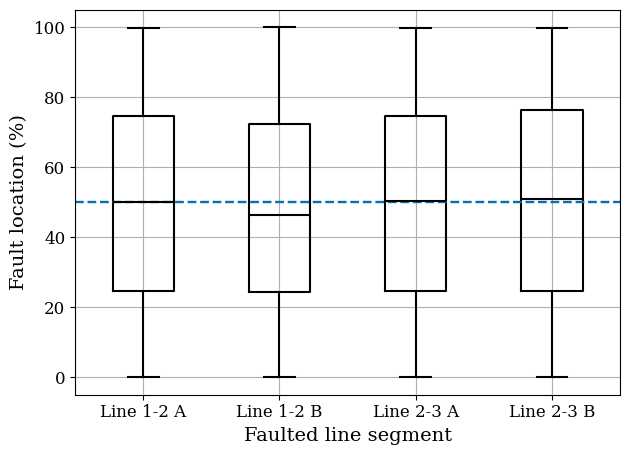

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- LaTeX-like font (Computer Modern) ---
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    }
)

# --- Minimalist styling (NeurIPS/ACM) ---
EDGE = "#000000"  # black
REFLINE = "#0072B2"  # Okabe–Ito blue (color-blind safe)

df_copy = df.copy()


def pretty_fault_target(ft: str) -> str:
    # Expected format: Line_1_2_a
    parts = ft.split("_")
    if len(parts) != 4:
        return ft
    _, bus1, bus2, circuit = parts
    return f"Line {bus1}–{bus2} {circuit.upper()}"


df_copy["fault_target_pretty"] = df_copy["fault_target"].map(pretty_fault_target)

order = ["Line 1–2 A", "Line 1–2 B", "Line 2–3 A", "Line 2–3 B"]
df_copy["fault_target_pretty"] = pd.Categorical(
    df_copy["fault_target_pretty"],
    categories=order,
    ordered=True,
)

# rename "Line 1–2 A" to "Line 1--2 A" for better fitting
df_copy["fault_target_pretty"] = df_copy["fault_target_pretty"].cat.rename_categories(
    {"Line 1–2 A": "Line 1-2 A", "Line 1–2 B": "Line 1-2 B", "Line 2–3 A": "Line 2-3 A", "Line 2–3 B": "Line 2-3 B"}
)
fig, ax = plt.subplots()

df_copy.boxplot(
    column="sc_location",
    by="fault_target_pretty",
    ax=ax,
    patch_artist=False,  # no fill
    boxprops=dict(color=EDGE, linewidth=1.5),
    medianprops=dict(color=EDGE, linewidth=1.5),
    whiskerprops=dict(color=EDGE, linewidth=1.5),
    capprops=dict(color=EDGE, linewidth=1.5),
    flierprops=dict(
        marker="o",
        markersize=2.5,
        markerfacecolor="none",
        markeredgecolor=EDGE,
        linewidth=1.2,
    ),
)

# 50% reference line
ax.axhline(50, linestyle="--", linewidth=1.7, color=REFLINE)

ax.set_xlabel("Faulted line segment")
ax.set_ylabel("Fault location (%)")

# Increase font size of labels
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
# Increase font size of tick labels
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.set_title("")
fig.suptitle("")

plt.tight_layout()

plt.savefig(
    "fault_location_coverage_per_line_segment.pdf",
    bbox_inches="tight",
)
plt.show()